## Simulation Code for thermal spreading of PCBA Board ##

Author: Jiong Chen

Date: February 11, 2025

Copyright: © 2025 Jiong Chen. All rights reserved.

Reference:
    1. Jain, Ankur. "Thermal spreading resistance from an isothermal source into a finite-thickness body." International Journal of Heat and Mass Transfer 220 (2024): 124946.

**1. SPREADING RESISTANCE IN COMPOUND RECTANGULAR CHANNELS**

*Testing Board Information*

- 40mm x 40mm board
- chip at center of the board with 5W power generation

*Boundary Condition*

- Top chip surface natural convection, 10W/m^2-K htc. (PCB board natural convection ignored)
- Bottom PCBA surface fixed temperature at 55C.
- k_z of PCBA (vertical direction) ~ 15W/m-K
- k of Chip ~ 15W/m-K


In [ ]:
# Implementation of "Reference 1"
import numpy as np
import numpy.linalg as la
import matplotlib.pyplot as plt

# Geometry Information
t_chip = 1e-3           # chip thickness, [m]
t_board = 10e-3         # PCBA board thickness, [m]
t_sink = 50e-3          # sink thickness, [m] guessing values

Q_chip = 5              # chip power, [W]
k_PCBA_z = 15           # PCBA board thermal conductivity along z-aixs, [W/m-K]
k_chip = 15             # chip thermal conductivity, [W/m-K]
T_BC = 55               # bottom surface boundary condition, [C]
T_env = 55              # environmental temperature, [C]230232
h_air = 10              # air side htc, [W/m^2-K]

L_PCBA = 400e-3;         # length of the board, [m]
W_PCBA = 400e-3;         # width of the board, [m]

L_chip = 10e-3;         # length of the chip, [m]
W_chip = 10e-3;         # width of the chip, [m]


# [Some const here...]
N = 150
Nz = 20
Nx = 20
A = L_PCBA/2
a = L_chip/2
t = t_sink
k = 120 # [W/m-K], casted-aluminum
h_sink = 100 # [W/m^2-K]

# delta = x / A
# eta = z / A
a_bar = a / A
t_bar = t / A
Bi_max = 1e6
Bi_sink = h_sink * A / k

# Generate LHX

#       Generate lam_n
lam_n = np.arange(0,N+1) * np.pi
lam_m = lam_n

# temporary input to compare with paper
a_bar = 0.1; t_bar = 0.4; Bi_sink = 2
A = 2; t = 0.4*A; a = 0.1*A

# calculate p0 and pn
p0 = -(t_bar + 1 / Bi_sink)
pn = -(Bi_sink*np.cosh(lam_n[1:]*t_bar) + lam_n[1:]*np.sinh(lam_n[1:]*t_bar)) / (Bi_sink*np.sinh(lam_n[1:]*t_bar) + lam_n[1:]*np.cosh(lam_n[1:]*t_bar))
p = np.hstack(([p0], pn))  # Using hstack to combine scalar and array

#       Initialize A
A_mat = np.zeros((N+1, N+1))
b = np.zeros(N+1)

#       Compute elements in A
# Eq.18, m = 0
A_mat[0,0] = 1/Bi_max - p[0] * a_bar
for n in range(1,N+1):
    A_mat[0,n] = -np.sin(lam_n[n] * a_bar) / lam_n[n]
b[0] = -a_bar

# Eq.19, m from 1 to N
for m in range(1,N+1):
    A_mat[m,0] = -p[0] * np.sin(lam_m[m]*a_bar) / lam_m[m]
    for n in range(1,1+N):
        if m==n:
            A_mat[m,n] = (lam_m[m]*p[m]/(2*Bi_max) - a_bar/2 - np.sin(2*lam_m[m]*a_bar)/(4*lam_m[m]))
        else:
            A_mat[m,n] = -(lam_n[n]*np.sin(lam_n[n]*a_bar)*np.cos(lam_m[m]*a_bar) - lam_m[m]*np.cos(lam_n[n]*a_bar)*np.sin(lam_m[m]*a_bar))/(lam_n[n]**2 - lam_m[m]**2)
    b[m] = -np.sin(lam_m[m]*a_bar) / lam_m[m]

#       Solve Ax=b
C = la.solve(A_mat, b)
print(np.allclose(np.dot(A_mat,C),b))

#       Calculate theta (temperature difference)

def cal_theta(xi, eta):
    theta_value = C[0]*(eta + p[0])
    for n in range(1,N+1):
        theta_value += C[n]*np.cos(lam_n[n]*xi) * (np.cosh(lam_n[n]*eta) + p[n]*np.sinh(lam_n[n]*eta))
    return theta_value

z = np.arange(0,t,t/Nz)
x = np.arange(0,A,A/Nx)
eta = z/A
xi = x/A
theta_dist = np.zeros((Nx, Nz))
for nx in range(Nx):
    for nz in range(Nz):
        theta_dist[nx, nz] = cal_theta(xi[nx],eta[nz])

In [ ]:
# Plot for (0, eta): fix xi=0, vary eta
plt.figure()
plt.plot(xi, theta_dist[:, 0], marker='o')
plt.xlabel(r'$\xi$')
plt.ylabel(r'$\theta$($\xi$, $\eta$=0)')
plt.title(r'$\theta$ vs. $\xi$ (at $\eta$=0)')
plt.grid(True)

# Plot for (xi, 0): fix eta=0, vary xi
plt.figure()
plt.plot(eta, theta_dist[0, :], marker='o', color='orange')
plt.xlabel(r'$\eta$')
plt.ylabel(r'$\theta$($\eta$=0, xi)')
plt.title(r'$\theta$ vs. $\eta$ (at $\xi$=0)')
plt.grid(True)

In [ ]:
# Create figure
fig, ax = plt.subplots(figsize=(6, 3))  # Set aspect ratio similar to your image

# Filled contour plot (smooth shading)
contourf = ax.contourf(xi, eta, theta_dist, levels=np.linspace(0, 1, 100), cmap='plasma', vmin=0, vmax=1)

# Contour lines (dashed)
contour = ax.contour(xi, eta, theta_dist, levels=np.linspace(0, 1, 10), colors='black', linestyles='dashed')

# Labels and formatting
ax.set_xlabel(r'$\xi$', fontsize=14)
ax.set_ylabel(r'$\eta$', fontsize=14)
ax.tick_params(axis='both', which='major', labelsize=12)

# **Invert y-axis to move origin to top-left**
ax.invert_yaxis()

# Add a label at the **bottom right** corner
ax.text(0.85, 0.05, r'$\bar{a} = 0.1$', fontsize=14, color='white', ha='right')

# Remove top and right borders for a cleaner look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add colorbar
cbar = fig.colorbar(contourf, ax=ax, orientation='vertical', shrink=0.8)
cbar.ax.tick_params(labelsize=12)
cbar.set_label(r'$\theta_{dist}$', fontsize=12)  # Label the colorbar

# Show plot
plt.show()

In [ ]:
import numpy as np
import numpy.linalg as la

def calc_p(t_bar, Bi_sink, lam_n):
    """
    Calculate the p coefficients.
    
    Parameters:
        t_bar : float
            Normalized sink thickness (t/A)
        Bi_sink : float
            Biot number for the sink
        lam_n : ndarray
            Array of eigenvalues, where lam_n = n*pi, for n=0,...,N
            
    Returns:
        ndarray
            Array of p coefficients
    """
    p0 = -(t_bar + 1 / Bi_sink)
    pn = -(Bi_sink * np.cosh(lam_n[1:] * t_bar) + lam_n[1:] * np.sinh(lam_n[1:] * t_bar)) / \
         (Bi_sink * np.sinh(lam_n[1:] * t_bar) + lam_n[1:] * np.cosh(lam_n[1:] * t_bar))
    return np.hstack(([p0], pn))

def calc_C(N, a_bar, Bi_max, lam_n, p):
    """
    Calculate the coefficients C by solving the linear system A_mat * C = b.
    
    Parameters:
        N : int
            Maximum index (number of terms)
        a_bar : float
            Normalized half-chip length (a/A)
        Bi_max : float
            Maximum Biot number
        lam_n : ndarray
            Array of eigenvalues, where lam_n = n*pi, for n=0,...,N
        p : ndarray
            Array of p coefficients computed from calc_p
            
    Returns:
        ndarray
            Array of coefficients C (solution to the system)
    """
    # Initialize A matrix and b vector
    A_mat = np.zeros((N+1, N+1))
    b = np.zeros(N+1)
    
    # Equation for m = 0 (first row)
    A_mat[0, 0] = 1 / Bi_max - p[0] * a_bar
    for n in range(1, N+1):
        A_mat[0, n] = -np.sin(lam_n[n] * a_bar) / lam_n[n]
    b[0] = -a_bar

    # Equations for m = 1 to N
    for m in range(1, N+1):
        A_mat[m, 0] = -p[0] * np.sin(lam_n[m] * a_bar) / lam_n[m]
        for n in range(1, N+1):
            if m == n:
                A_mat[m, n] = (lam_n[m] * p[m] / (2 * Bi_max) - a_bar / 2 -
                               np.sin(2 * lam_n[m] * a_bar) / (4 * lam_n[m]))
            else:
                A_mat[m, n] = -(lam_n[n] * np.sin(lam_n[n] * a_bar) * np.cos(lam_n[m] * a_bar) -
                                lam_n[m] * np.cos(lam_n[n] * a_bar) * np.sin(lam_n[m] * a_bar)) / \
                               (lam_n[n]**2 - lam_n[m]**2)
        b[m] = -np.sin(lam_n[m] * a_bar) / lam_n[m]

    # Solve the linear system A_mat * C = b
    C = la.solve(A_mat, b)
    return C

def calc_R_sp(k, L, a_bar, lam_n, C, p):
    """
    Calculate the spreading resistance R_sp based on:
    
        k * L * R_sp = -[C0*a_bar + sum_{n=1 to N}( Cn * pn * sin(lam_n[n] * a_bar ))]^-1 + p0
    
    which can be rewritten as:
    
        k * L * R_sp = p0 - 1/X
    
    where 
        X = C0*a_bar + sum_{n=1 to N}( Cn * pn * sin(lam_n[n] * a_bar ))
    
    and p0 = p[0].
    
    Parameters
    ----------
    k : float
        Thermal conductivity [W/m-K].
    L : float
        Characteristic length [m] used in the above formula.
    a_bar : float
        Normalized half-length of the heat source (a/A).
    lam_n : ndarray
        Eigenvalues (n*pi for n = 0..N).
    C : ndarray
        Array of coefficients C0..CN (solution from your linear system).
    p : ndarray
        Array of p-values p0..pN (from your calc_p function).
    
    Returns
    -------
    R_sp : float
        Spreading resistance [K/W].
    """
    
    # Number of terms (N+1) is given by the length of C
    # We assume p and lam_n have matching length.
    N = len(C) - 1
    
    # p0 is p[0]
    p0 = p[0]
    
    # X = C0*a_bar + sum_{n=1..N} [C[n]*p[n]*sin(lam_n[n]*a_bar)]
    X = C[0] * a_bar
    for n in range(1, N+1):
        X += C[n] * p[n] * np.sin(lam_n[n] * a_bar)
    
    # k * L * R_sp = p0 - 1/X
    # => R_sp = (p0 - 1/X) / (k * L)
    kL_R_sp = p0 - 1.0/X
    R_sp = kL_R_sp / (k * L)
    
    return R_sp

if __name__ == '__main__':
    # ----------------------------
    # Input Parameters and Settings
    # ----------------------------
    N = 150  # Number of terms in the series
    
    # Temporary inputs for comparison with the paper
    a_bar = 0.1  # normalized half-chip length (a/A)
    t_bar = 0.4  # normalized sink thickness (t/A)
    Bi_sink = 2  # Biot number for the sink
    Bi_max = 1e6
    k = 120      # thermal conductivity of the heat sink, casted-aluminum [W/m-K]
    L = 10e-3    # depth of the heat sink
    
    # For the temporary inputs, redefine A, t, a (if needed)
    A = 2          # characteristic length (e.g., half the board length)
    t = 0.4 * A    # sink thickness
    a = 0.1 * A    # chip half-length
    

    # Generate eigenvalues: lam_n = n * pi, for n = 0, 1, 2, ... , N
    lam_n = np.arange(0, N+1) * np.pi

    # ----------------------------
    # Compute Coefficients
    # ----------------------------
    # Calculate p coefficients
    p = calc_p(t_bar, Bi_sink, lam_n)
    
    # Calculate C coefficients by solving the linear system
    C = calc_C(N, a_bar, Bi_max, lam_n, p)
    
    R_sp= calc_R_sp(k, L, a_bar, lam_n, C, p)
    print(R_sp)
    # Optional: Verify the solution by checking that A_mat * C equals b.
    # (Reconstruct A_mat and b if needed for debugging.)
    A_mat = np.zeros((N+1, N+1))
    b = np.zeros(N+1)
    
    A_mat[0, 0] = 1 / Bi_max - p[0] * a_bar
    for n in range(1, N+1):
        A_mat[0, n] = -np.sin(lam_n[n] * a_bar) / lam_n[n]
    b[0] = -a_bar
    
    for m in range(1, N+1):
        A_mat[m, 0] = -p[0] * np.sin(lam_n[m] * a_bar) / lam_n[m]
        for n in range(1, N+1):
            if m == n:
                A_mat[m, n] = (lam_n[m] * p[m] / (2 * Bi_max) - a_bar / 2 -
                               np.sin(2 * lam_n[m] * a_bar) / (4 * lam_n[m]))
            else:
                A_mat[m, n] = -(lam_n[n] * np.sin(lam_n[n] * a_bar) * np.cos(lam_n[m] * a_bar) -
                                lam_n[m] * np.cos(lam_n[n] * a_bar) * np.sin(lam_n[m] * a_bar)) / \
                               (lam_n[n]**2 - lam_n[m]**2)
        b[m] = -np.sin(lam_n[m] * a_bar) / lam_n[m]
    
    if np.allclose(np.dot(A_mat, C), b):
        print("Solution verified: A_mat * C equals b")
    else:
        print("Solution verification failed")


In [ ]:
import numpy as np

# Define the constants a, b, c, dk1
a = 5e-3  # Example values
b = 5e-3
c = 30e-3
d = 30e-3
k1 = 30
k2 = 30
t1 = 2e-3
t2 = 2e-3
h = 5

# Define N, the number of terms to approximate the infinite series
N = 100
kappa = k2/k1
alpha = (1 - kappa) / (1 + kappa)
L = 10
Bi = h*L/k1 

def phi(zeta, alpha, kappa, L, Bi, t1, t2):
    # Convert i to 1j for imaginary numbers in Python
    term1_numerator = alpha * (kappa * L * zeta - Bi) * np.exp(4 * t1 * zeta) + (kappa * L * zeta - Bi) * np.exp(2 * t1 * zeta)
    term1_denominator = alpha * (kappa * L * zeta - Bi) * np.exp(4 * t1 * zeta) - (kappa * L * zeta - Bi) * np.exp(2 * t1 * zeta)
    
    term2_numerator = (kappa * L * zeta + Bi) * np.exp(2 * (2 * t1 + t2) * zeta) + alpha * (kappa * L * zeta + Bi) * np.exp(2 * (t1 + t2) * zeta)
    term2_denominator = (kappa * L * zeta + Bi) * np.exp(2 * (2 * t1 + t2) * zeta) - alpha * (kappa * L * zeta + Bi) * np.exp(2 * (t1 + t2) * zeta)
    
    return (term1_numerator + term2_numerator) / (term1_denominator + term2_denominator)

# First term
delta = np.linspace(0.1, 10, N)  # Avoid division by zero
term1 = sum((np.sin(a * delta) ** 2) / (delta ** 3) * phi(delta, alpha, kappa, L, Bi, t1, t2))

# Second term
lambda_ = np.linspace(0.1, 10, N)  # Avoid division by zero
term2 = sum((np.sin(b * lambda_) ** 2) / (lambda_ ** 3) * phi(lambda_, alpha, kappa, L, Bi, t1, t2))

# Third term
# delta = np.linspace(0.1, 10, N)  # Reuse delta
# lambda_ = np.linspace(0.1, 10, N)  # Reuse lambda_
term3 = 0
for m in range(1, N + 1):
    for n in range(1, N + 1):
        beta = np.sqrt(delta[m-1]**2 + lambda_[n-1]**2)
        term = (np.sin(a * delta[m-1]) ** 2 * np.sin(b * lambda_[n-1]) ** 2) / (delta[m-1]**2 * lambda_[n-1]**2 * beta)
        term3 += term * phi(beta, alpha, kappa, L, Bi, t1, t2)
        
# Total Rs
Rs = (1 / (2 * a**2 * c * d * k1) * term1 +
      1 / (2 * b**2 * c * d * k1) * term2 +
      1 / (a**2 * b**2 * c * d * k1) * term3)

print("Rs =", Rs)

In [ ]:
import numpy as np

# Constants
a = 9e-3
b = 9e-3
c = 10e-3
d = 10e-3
k1 = 30
k2 = 40
t1 = 2e-3
t2 = 2e-3
h = 5

# Constants derived from input
kappa = k2 / k1
alpha = (1 - kappa) / (1 + kappa)
L = c
Bi = h * L / k1

def phi(zeta, alpha, kappa, L, Bi, t1, t2):
    # Convert i to 1j for imaginary numbers in Python
    term1_numerator = alpha * (kappa * L * zeta - Bi) * np.exp(4 * t1 * zeta) + (kappa * L * zeta - Bi) * np.exp(2 * t1 * zeta)
    term1_denominator = alpha * (kappa * L * zeta - Bi) * np.exp(4 * t1 * zeta) - (kappa * L * zeta - Bi) * np.exp(2 * t1 * zeta)
    
    term2_numerator = (kappa * L * zeta + Bi) * np.exp(2 * (2 * t1 + t2) * zeta) + alpha * (kappa * L * zeta + Bi) * np.exp(2 * (t1 + t2) * zeta)
    term2_denominator = (kappa * L * zeta + Bi) * np.exp(2 * (2 * t1 + t2) * zeta) - alpha * (kappa * L * zeta + Bi) * np.exp(2 * (t1 + t2) * zeta)
    
    return (term1_numerator + term2_numerator) / (term1_denominator + term2_denominator)

# N values
N_values = [5, 10, 20, 30, 40, 50, 100, 200, 300, 400, 500]
Rs_values = []

for N in N_values:
    # Delta and lambda values
    delta = np.arange(1, N + 1)
    lambda_ = np.arange(1, N + 1)

    # First term
    term1 = sum((np.sin(a * delta) ** 2) / (delta ** 3) * phi(delta, alpha, kappa, L, Bi, t1, t2))

    # Second term
    term2 = sum((np.sin(b * lambda_) ** 2) / (lambda_ ** 3) * phi(lambda_, alpha, kappa, L, Bi, t1, t2))

    # Third term
    term3 = 0
    for m in range(1, N + 1):
        for n in range(1, N + 1):
            beta = np.sqrt(delta[m-1]**2 + lambda_[n-1]**2)
            term = (np.sin(a * delta[m-1]) ** 2 * np.sin(b * lambda_[n-1]) ** 2) / (delta[m-1]**2 * lambda_[n-1]**2 * beta)
            term3 += term * phi(beta, alpha, kappa, L, Bi, t1, t2)
            
    # Total Rs
    Rs = (1 / (2 * c * d * k1) * term1 +
          1 / (2 * b**2 * c * d * k1) * term2 +
          1 / (a**2 * b**2 * c * d * k1) * term3) * t1
    Rs_values.append(Rs)

In [ ]:

import matplotlib.pyplot as plt

# Plot Rs vs N
plt.figure(figsize=(10, 6))
plt.plot(N_values, Rs_values, marker='o', linestyle='-', color='b')
plt.xlabel('Number of Terms (N)')
plt.ylabel('Value of Rs')
plt.title('Convergence of Rs with Increasing N')
plt.grid(True)
# plt.xscale('log')
# plt.yscale('log')
plt.show()

In [ ]:
# Plot phi vs delta
plt.figure(figsize=(10, 6))
plt.plot(delta, phi(lambda_, alpha, kappa, L, Bi, t1, t2), label='phi(delta)')
plt.ylim(0,18)
plt.xlabel('delta')
plt.ylabel('phi(delta)')
plt.title('Plot of phi(delta) vs delta')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Constants and domain setup
L = 1.0           # length of the domain in meters
N = 20            # number of elements
dx = L / N        # distance between nodes
k = 120             # thermal conductivity in W/mK (example value)
h = 10            # convective heat transfer coefficient in W/m^2K (example value)
T_wall = 60
T_inf = 35

# Generate the grid points
x = np.linspace(0, L, N + 1)
dx = x[1]-x[0]

# Initialize A matrix and b vector
A = np.zeros((N+1, N+1))
b = np.zeros(N+1)

# Fill the A matrix
for i in range(1, N):
    A[i, i-1] = A[i, i+1] = 1
    A[i, i] = -2

# Constant Surface Temp BC at x=0 (T = 60)
A[0, 0] = 1
b[0] = T_wall

# Convective BC at x=1
A[N, N-1] = -1
A[N, N] = 1 + h * dx / k

b[N] = h * dx / k * T_inf

# Initialize the solution vector u to zero
u = np.zeros(N+1)

# Extract the diagonal elements of A and compute their inverses
D = np.diag(A)
Di = 1.0 / D

# Set tolerance for the convergence check
tolerance = 1e-6
max_iterations = 1000
error = 1
errors = []

# Perform Jacobi iteration
while error > tolerance:
    u_new = u + Di * (b - A.dot(u))  # Update step using element-wise multiplication
    error = np.linalg.norm(u_new - u, np.inf)
    errors.append(error)  # Store the current error
    
    if error < tolerance:
        print(f'Converged in {k+1} iterations.')
        break
    u = u_new

print("Solution u:", u)

# Optional: Plotting the error convergence (if needed)
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(errors, marker='o', linestyle='-')
plt.xlabel('Iteration Number')
plt.ylabel('Error')
plt.title('Error Convergence in Jacobi Iteration')
plt.yscale('log')  # Logarithmic scale for better visibility of convergence
plt.grid(True)
plt.show()


# 1-D conduction #

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def compute_temperature(N, k=120, h=10, T_wall=60, T_inf=35, L=1.0, q_flux=5.0, tolerance=1e-6):
    print(N)
    dx = L / N
    x = np.linspace(0, L, N + 1)
    A = np.zeros((N+1, N+1))
    b = np.zeros(N+1)
    
    # Fill the A matrix
    for i in range(1, N):
        A[i, i-1] = A[i, i+1] = 1
        A[i, i] = -2

    # Boundary conditions
    # A[0, 0] = 1  # Dirichlet BC at x=0
    # b[0] = T_wall
    
    A[0, 0] = 1
    A[0, 1] = -1
    r = 5e-3
    b[0] = q_flux/k*dx
    
    # A[0,0] = 1   # Adiabatic at x=0
    # A[0,1] = -1
    
    A[N, N-1] = -1  # Convective BC at x=1
    A[N, N] = 1 + h * dx / k
    b[N] = h * dx / k * T_inf

    # Initial guess
    u = np.zeros(N+1)
    D = np.diag(A)
    Di = 1.0 / D

    # Jacobi iteration
    error = 1
    errors = []
    iter = 0
    while error > tolerance:
        iter += 1
        u_new = u + Di * (b - A.dot(u))
        error = np.linalg.norm(u_new - u, np.inf)
        u = u_new
    print(N, iter)
    return x, u

# Different N values for simulation
N_values = [10, 20, 40, 80, 100]
plt.figure(figsize=(12, 8))

for N in N_values:
    x, u = compute_temperature(N)
    plt.plot(x, u, label=f'N={N}')

plt.title('Temperature Distribution along the Rod for Different N')
plt.xlabel('Position along the rod (x)')
plt.ylabel('Temperature (C)')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def compute_temperature(N, k=120, h=10, T_wall=60, T_inf=35, L=1.0, q_flux=5.0, tolerance=1e-6):
    print(N)
    dx = L / N
    x = np.linspace(0, L, N + 1)
    A = np.zeros((N+1, N+1))
    b = np.zeros(N+1)
    
    # Fill the A matrix
    for i in range(1, N):
        A[i, i-1] = A[i, i+1] = 1
        A[i, i] = -2

    # Boundary conditions
    # A[0, 0] = 1  # Dirichlet BC at x=0
    # b[0] = T_wall
    
    A[0, 0] = 1
    A[0, 1] = -1
    r = 5e-3
    b[0] = q_flux/k*dx
    
    # A[0,0] = 1   # Adiabatic at x=0
    # A[0,1] = -1
    
    A[N, N-1] = -1  # Convective BC at x=1
    A[N, N] = 1 + h * dx / k
    b[N] = h * dx / k * T_inf
    print(A[:6,:6])
    # Initial guess
    u = np.zeros(N+1)
    D = np.diag(A)
    Di = 1.0 / D

    # Jacobi iteration
    error = 1
    errors = []
    iter = 0
    while error > tolerance:
        iter += 1
        u_new = u + Di * (b - A.dot(u))
        error = np.linalg.norm(u_new - u, np.inf)
        u = u_new
    print(N, iter)
    return x, u

# Different N values for simulation
# N_values = [10, 20, 40, 80, 100]
N_values = [10]
plt.figure(figsize=(12, 8))

for N in N_values:
    x, u = compute_temperature(N)
    plt.plot(x, u, label=f'N={N}')

plt.title('Temperature Distribution along the Rod for Different N')
plt.xlabel('Position along the rod (x)')
plt.ylabel('Temperature (C)')
plt.legend()
plt.grid(True)
plt.show()


# 2-D conduction #

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

k=120; h=10; T_wall=60; T_inf=35; L=0.3; q_flux=5.0

def tridiag(n, sub_val=-1, main_val=2, super_val=-1):
    """
    Create a dense tridiagonal matrix of size n x n.

    Parameters:
        n (int): Size of the matrix (number of rows/columns).
        sub_val (float): Value for the sub-diagonal elements (default: -1).
        main_val (float): Value for the main diagonal elements (default: 2).
        super_val (float): Value for the super-diagonal elements (default: -1).

    Returns:
        A (ndarray): A tridiagonal matrix.
    """
    sub_diag = sub_val * np.ones(n-1)
    main_diag = main_val * np.ones(n)
    super_diag = super_val * np.ones(n-1)
    
    A = np.diag(main_diag, 0) + np.diag(sub_diag, -1) + np.diag(super_diag, 1)
    return A
Nx = 30; Ny = 10; Nz = 10
Lx = 1.0; Ly = 1.0; Lz = 1.0
dx = Lx/Nx; dy = Ly / Ny; dz = Lz / Nz
Ax = tridiag(Nx)/dx**2; Ay = tridiag(Ny)/dy**2; Az = tridiag(Nz)/dz**2
Ix = np.identity(Nx); Iy = np.identity(Ny); Iz = np.identity(Nz)

A_ini = np.kron(Iy, Ax) + np.kron(Ay,Ix) # initialize A
Ashape = np.size(A_ini[:,1])
b = np.zeros(Ashape)
A_final = A_ini.copy()

# top edge BC [adiabatic wall]
for i in range(Nx):
        A_final[i,:] = 0
        A_final[i,i] = 1/dx**2
        A_final[i,i+Nx] = -1/dx**2

# left edge BC [constant surface temperature]
for i in range(Ny):
    if i == 0 or i == Ny-1:
        continue
    else:
        A_final[i*Nx,i*Nx] = 1/dx**2
        A_final[i*Nx,0:i*Nx] = 0
        A_final[i*Nx,i*Nx+1:] = 0
        b[i*Nx] = T_wall/dx**2
        
# right edge BC [convective BC]
for i in range(Ny):
    if i == 0 or i == Ny-1:
        continue
    else:
        A_final[(i+1)*Nx-1,(i+1)*Nx-1] = -2/dy**2 - 1/dx**2 - h/k/dx
        A_final[(i+1)*Nx-1,(i+1)*Nx-1-Nx] = 1/dy**2
        A_final[(i+1)*Nx-1,(i+1)*Nx-1+Nx] = 1/dy**2
        A_final[(i+1)*Nx-1,(i+1)*Nx-2] = 1/dx**2
        b[(i+1)*Nx-1] = -h*T_inf/k/dx

# bottom edge BC [adiabatic wall]
for i in range(Nx):
        A_final[(Ny-1)*Nx+i,:] = 0
        A_final[(Ny-1)*Nx+i,(Ny-1)*Nx+i] = 1/dx**2
        A_final[(Ny-1)*Nx+i,(Ny-1)*Nx+i-Nx] = -1/dx**2
        
u = np.zeros(Ashape)
D = np.diag(A_final)
Di = 1.0 / D

# Jacobi iteration
tolerance = 1e-6
error = 1
errors = []
iter = 0
while error > tolerance:
    iter += 1
    u_new = u + Di * (b - A_final.dot(u))
    error = np.linalg.norm(u_new - u, np.inf)
    u = u_new
    print(error, iter)

x = np.linspace(0, Lx, Nx)
y = np.linspace(0, Ly, Ny)

# Create a meshgrid for plotting
X, Y = np.meshgrid(x, y, indexing='ij')

T_final = u.reshape(Ny,Nx)
# Plot contour
plt.figure(figsize=(6, 5))
contour = plt.contourf(X, Y, T_final.T, levels=20, cmap='viridis')  # More levels for smoother transitions
plt.colorbar(label='Z Value')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Smooth Contour Plot of Z over X-Y Plane')

# Add contour lines for better visualization
plt.contour(X, Y, T_final.T, levels=20, colors='black', linewidths=0.5, alpha=0.5)

plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_matrix(A):
    """
    Plots a matrix using dots to visualize its structure.
    
    Parameters:
        A (ndarray): The matrix to be visualized.
    """
    plt.figure(figsize=(6, 6))
    plt.imshow(A != 0, cmap='gray_r', interpolation='nearest')  # Shows nonzero elements as dots
    plt.title("Matrix Structure")
    plt.xlabel("Columns")
    plt.ylabel("Rows")
    plt.show()
tmp = np.kron(Iy, Ax) + np.kron(Ay,Ix)
plot_matrix(A_final)
np.set_printoptions(suppress=True, precision=2)
print(A_final[-8:,-8:])
print(A_final[1,1+Nx])

# 2-D with partial heat source #

60.0 1
15.0 2
7.5 3
4.6875 4
3.28125 5
2.8125 6
2.4169921875 7
2.0947265625 8
1.8328857421875 9
1.61865234375 10
1.4416122436523438 11
1.3330078125 12
1.2599372863769531 13
1.2599372863769531 14
1.175401210784912 15
1.175401210784912 16
1.091026347130537 17
1.091026347130537 18
1.0113382106646895 19
1.0113382106646895 20
0.9378544942592271 21
0.9378544942592271 22
0.8708133883556002 23
0.8708133883556002 24
0.8099225158991938 25
0.8099225158991938 26
0.7546902557393231 27
0.7546902557393231 28
0.7045734475192731 29
0.7045734475192731 30
0.6590421193123817 31
0.6590421193123817 32
0.6176059553278641 33
0.6176059553278641 34
0.5798229802309045 35
0.5798229802309045 36
0.545300077191385 37
0.545300077191385 38
0.51368993884536 39
0.51368993884536 40
0.4846866670798349 41
0.4846866670798349 42
0.4580210798890043 43
0.4580210798890043 44
0.4334562122907677 45
0.4334562122907677 46
0.4118831553531592 47
0.4107832145207553 48
0.3944099006703361 49
0.389817710679921 50
0.377948859129436 51
0.3

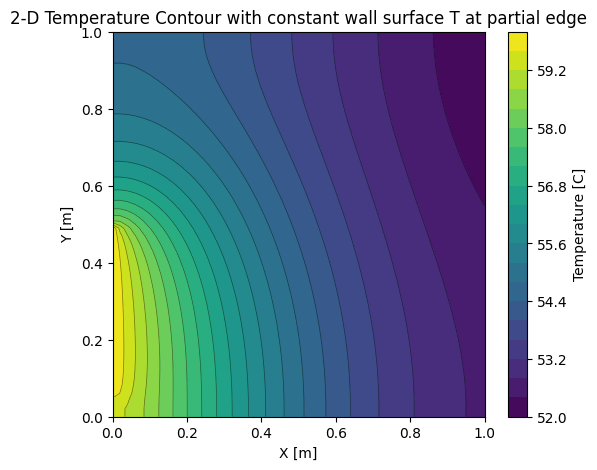

In [2]:
import numpy as np
import matplotlib.pyplot as plt

k=120; h=10; T_wall=60; T_inf=35; L=0.3; q_flux=5.0

def tridiag(n, sub_val=-1, main_val=2, super_val=-1):
    """
    Create a dense tridiagonal matrix of size n x n.

    Parameters:
        n (int): Size of the matrix (number of rows/columns).
        sub_val (float): Value for the sub-diagonal elements (default: -1).
        main_val (float): Value for the main diagonal elements (default: 2).
        super_val (float): Value for the super-diagonal elements (default: -1).

    Returns:
        A (ndarray): A tridiagonal matrix.
    """
    sub_diag = sub_val * np.ones(n-1)
    main_diag = main_val * np.ones(n)
    super_diag = super_val * np.ones(n-1)
    
    A = np.diag(main_diag, 0) + np.diag(sub_diag, -1) + np.diag(super_diag, 1)
    return A
Nx = 50; Ny = 50; Nz = 10
Lx = 1.0; Ly = 1.0; Lz = 1.0
dx = Lx/Nx; dy = Ly / Ny; dz = Lz / Nz
Ax = tridiag(Nx)/dx**2; Ay = tridiag(Ny)/dy**2; Az = tridiag(Nz)/dz**2
Ix = np.identity(Nx); Iy = np.identity(Ny); Iz = np.identity(Nz)

A_ini = np.kron(Iy, Ax) + np.kron(Ay,Ix) # initialize A
Ashape = np.size(A_ini[:,1])
b = np.zeros(Ashape)
A_final = A_ini.copy()

# top edge BC [adiabatic wall]
for i in range(Nx):
        A_final[i,:] = 0
        A_final[i,i] = 1/dx**2
        A_final[i,i+Nx] = -1/dx**2

# left edge BC [1/6 to 1/2 are constant T, and rest are adiabatic]
for i in range(Ny):
    if i == 0 or i == Ny-1:
        continue
    elif i > 2 and i < Ny/2:
        A_final[i*Nx,:] = 0
        A_final[i*Nx,i*Nx] = 1/dx**2
        A_final[i*Nx,0:i*Nx] = 0
        A_final[i*Nx,i*Nx+1:] = 0
        b[i*Nx] = T_wall/dx**2
    else:
        A_final[i*Nx,:] = 0
        A_final[i*Nx,i*Nx] = 1/dx**2
        A_final[i*Nx,i*Nx+1] = -1/dx**2
        
# right edge BC [convective BC]
for i in range(Ny):
    if i == 0 or i == Ny-1:
        continue
    else:
        A_final[(i+1)*Nx-1,(i+1)*Nx-1] = -2/dy**2 - 1/dx**2 - h/k/dx
        A_final[(i+1)*Nx-1,(i+1)*Nx-1-Nx] = 1/dy**2
        A_final[(i+1)*Nx-1,(i+1)*Nx-1+Nx] = 1/dy**2
        A_final[(i+1)*Nx-1,(i+1)*Nx-2] = 1/dx**2
        b[(i+1)*Nx-1] = -h*T_inf/k/dx

# bottom edge BC [adiabatic wall]
for i in range(Nx):
        A_final[(Ny-1)*Nx+i,:] = 0
        A_final[(Ny-1)*Nx+i,(Ny-1)*Nx+i] = 1/dx**2
        A_final[(Ny-1)*Nx+i,(Ny-1)*Nx+i-Nx] = -1/dx**2
        
u = np.zeros(Ashape)
D = np.diag(A_final)
Di = 1.0 / D

# Jacobi iteration
tolerance = 1e-3
error = 1
errors = []
iter = 0
while error > tolerance:
    iter += 1
    u_new = u + Di * (b - A_final.dot(u))
    error = np.linalg.norm(u_new - u, np.inf)
    u = u_new
    print(error, iter)

x = np.linspace(0, Lx, Nx)
y = np.linspace(0, Ly, Ny)

# Create a meshgrid for plotting
X, Y = np.meshgrid(x, y, indexing='ij')

T_final = u.reshape(Ny,Nx)
# Plot contour
plt.figure(figsize=(6, 5))
contour = plt.contourf(X, Y, T_final.T, levels=20, cmap='viridis')  # More levels for smoother transitions
plt.colorbar(label='Temperature [C]')
plt.xlabel('X [m]')
plt.ylabel('Y [m]')
plt.title('2-D Temperature Contour with constant wall surface T at partial edge')

# Add contour lines for better visualization
plt.contour(X, Y, T_final.T, levels=20, colors='black', linewidths=0.5, alpha=0.5)

plt.show()